# So sánh kết quả huấn luyện Faster R-CNN, RCNN-ODAM và SAB-ODAM

Notebook này đọc trực tiếp artifact trong `results/`, ưu tiên các run hiện tại:

- `results/faster_rcnn` - Faster R-CNN baseline; nhãn `scratch`/`ImageNet backbone` được suy ra từ `run_config.json`
- `results/baseline/faster_rcnn_imagenet_ddp_30e` - Faster R-CNN ImageNet-backbone baseline nếu có
- `results/rcnn_odam_train`
- `results/rcnn_odam_train_odam_nms`
- `results/rcnn_odam_train_schedule_odam_nms`
- `results/sab_odam_train`
- `results/sab_odam_train_imagenet_ddp_30e` - SAB-ODAM ImageNet-backbone run nếu có

Notebook chuẩn hóa metric giữa Faster R-CNN baseline, RCNN-ODAM và SAB-ODAM. Parser `metrics.csv` có cơ chế phục hồi các row SAB có thêm cột `loss_sab_*` sau epoch warmup, để không đọc lệch `val_map50`/`val_map_50_95`. Hãy chạy lại toàn bộ notebook sau khi có kết quả train mới.


In [1]:
from __future__ import annotations

import csv
import json
import os
import sys
from pathlib import Path
from typing import Any

os.environ.setdefault("MPLBACKEND", "Agg")
os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cache")


def find_project_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    candidates = [start, *start.parents]
    for path in candidates:
        if (path / "results").exists() and (path / "rcnn_odamTrain").exists():
            return path
    for path in candidates:
        if (path / "results").exists():
            return path
    return start


PROJECT_ROOT = find_project_root()
RESULTS_ROOT = PROJECT_ROOT / "results"
REPORT_DIR = PROJECT_ROOT / "notebooks" / "compare_training_results_figures"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# Some notebook launchers resolve the kernelspec to system Python even when this
# repo's .venv is the intended runtime. Add the repo venv site-packages before
# importing pandas/numpy/matplotlib so the notebook remains runnable there.
for site_packages in sorted((PROJECT_ROOT / ".venv" / "lib").glob("python*/site-packages")):
    site_path = str(site_packages)
    if site_path not in sys.path:
        sys.path.insert(0, site_path)

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
    HAS_MATPLOTLIB = True
except ModuleNotFoundError:
    plt = None
    HAS_MATPLOTLIB = False
    print("matplotlib is not installed; tables will run and plot cells will be skipped.")

try:
    from IPython.display import display
except Exception:  # pragma: no cover - only used outside notebooks
    def display(obj):
        if hasattr(obj, "to_string"):
            print(obj.to_string(index=False))
        else:
            print(obj)

pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)
if HAS_MATPLOTLIB:
    plt.style.use("seaborn-v0_8-whitegrid")

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"RESULTS_ROOT = {RESULTS_ROOT}")
print(f"REPORT_DIR = {REPORT_DIR}")


PROJECT_ROOT = /home/thanhmay/workspace/xai-object-detection
RESULTS_ROOT = /home/thanhmay/workspace/xai-object-detection/results
REPORT_DIR = /home/thanhmay/workspace/xai-object-detection/notebooks/compare_training_results_figures


## 1. Phát hiện run và kiểm tra artifact

Bảng này cho biết mỗi run có đủ `metrics.csv`, `test_metrics.json`, config và checkpoint hay không. Cột `preferred` đánh dấu các đường dẫn chính nên dùng trong báo cáo hiện tại; các run khác vẫn được tự động đưa vào inventory để tránh bỏ sót dữ liệu.


In [2]:
PREFERRED_RUN_CANDIDATES = [
    (
        "Faster R-CNN",
        [
            RESULTS_ROOT / "faster_rcnn",
            RESULTS_ROOT / "baseline" / "faster_rcnn_imagenet_ddp_30e",
            RESULTS_ROOT / "baseline" / "faster_rcnn_imagenet",
            RESULTS_ROOT / "baseline" / "faster_rcnn_scratch_ddp_30e",
            RESULTS_ROOT / "baseline" / "faster_rcnn_scratch",
        ],
    ),
    (
        "RCNN-ODAM",
        [
            RESULTS_ROOT / "rcnn_odam_train",
            RESULTS_ROOT / "rcnn_odam_train_fixed",
            RESULTS_ROOT / "rcnn_odam_train_ddp",
        ],
    ),
    (
        "RCNN-ODAM + ODAM-NMS",
        [
            RESULTS_ROOT / "rcnn_odam_train_odam_nms",
        ],
    ),
    (
        "RCNN-ODAM + Schedule + ODAM-NMS",
        [
            RESULTS_ROOT / "rcnn_odam_train_schedule_odam_nms",
        ],
    ),
    (
        "SAB-ODAM",
        [
            RESULTS_ROOT / "sab_odam_train",
            RESULTS_ROOT / "sab_odam_train_imagenet_ddp_30e",
            RESULTS_ROOT / "sab_odam_train_imagenet",
        ],
    ),
]


RUN_LABEL_OVERRIDES = {
    "rcnn_odam_train": "RCNN-ODAM",
    "rcnn_odam_train_odam_nms": "RCNN-ODAM + ODAM-NMS",
    "rcnn_odam_train_schedule_odam_nms": "RCNN-ODAM + Schedule + ODAM-NMS",
}


def rel(path: Path | None) -> str | None:
    if path is None:
        return None
    try:
        return str(path.resolve().relative_to(PROJECT_ROOT))
    except Exception:
        return str(path)


def read_json(path: Path | None) -> dict[str, Any]:
    if not path or not path.exists():
        return {}
    with path.open("r", encoding="utf-8") as f:
        return json.load(f)


def first_existing_config(run_dir: Path) -> Path | None:
    for name in ("run_config.json", "config.json", "args.json"):
        path = run_dir / name
        if path.exists():
            return path
    matches = sorted(run_dir.glob("*config*.json"))
    return matches[0] if matches else None


def nested_value(obj: dict[str, Any], *paths: str, default: Any = None) -> Any:
    for path in paths:
        cur: Any = obj
        ok = True
        for part in path.split("."):
            if isinstance(cur, dict) and part in cur:
                cur = cur[part]
            else:
                ok = False
                break
        if ok:
            return cur
    return default


def init_label(detector_weights: Any, backbone_weights: Any) -> str:
    detector = str(detector_weights).lower() if detector_weights is not None else ""
    backbone = str(backbone_weights).lower() if backbone_weights is not None else ""
    if detector in {"coco", "default", "pretrained"}:
        return "COCO detector"
    if detector in {"imagenet", "backbone", "backbone-only"}:
        return "ImageNet backbone"
    if backbone in {"default", "imagenet", "pretrained", "coco"}:
        return "ImageNet backbone"
    if detector in {"scratch", "none", "random"} or backbone in {"scratch", "none", "random"}:
        return "scratch"
    return "unknown init"


def infer_run_label(run_dir: Path, fallback_label: str, config_path: Path | None = None) -> str:
    cfg = read_json(config_path or first_existing_config(run_dir))
    detector_weights = nested_value(cfg, "arguments.weights", "args.weights")
    backbone_weights = nested_value(cfg, "arguments.backbone_weights", "args.backbone_weights", "config.backbone_weights")
    init = init_label(detector_weights, backbone_weights)
    odam_nms = bool(nested_value(cfg, "config.odam_nms", "args.odam_nms", default=False))
    sab_odam = bool(nested_value(cfg, "config.sab_odam", "args.sab_odam", default=False))

    name = run_dir.name
    if sab_odam or name.startswith("sab_odam"):
        family = "SAB-ODAM"
    elif name == "rcnn_odam_train_schedule_odam_nms" or "schedule" in name:
        family = "RCNN-ODAM + Schedule + ODAM-NMS"
    elif name == "rcnn_odam_train_odam_nms" or ("odam_nms" in name and not sab_odam):
        family = "RCNN-ODAM + ODAM-NMS"
    elif name.startswith("rcnn_odam"):
        family = "RCNN-ODAM"
    elif name.startswith("faster_rcnn") or "faster_rcnn" in name:
        family = "Faster R-CNN"
    else:
        family = RUN_LABEL_OVERRIDES.get(name, fallback_label)

    if family == "RCNN-ODAM" and odam_nms:
        family = "RCNN-ODAM + ODAM-NMS"

    sab_variant_labels = {
        "sab_odam_train": "",
        "sab_odam_train_imagenet": "",
        "sab_odam_train_imagenet_ddp_30e": "",
        "sab_ablation_match_only": "match only",
        "sab_ablation_match_scale": "match + scale",
        "sab_ablation_tuned_loss": "tuned loss",
        "sab_ablation_late_light": "late light",
        "sab_odam_train_tuned_loss": "tuned loss",
    }
    if family == "SAB-ODAM":
        variant = sab_variant_labels.get(name)
        if variant is None and name.startswith("sab_") and name != "sab_odam_train":
            variant = name.removeprefix("sab_").replace("_", " ")
        if variant:
            family = f"{family} [{variant}]"
    return f"{family} ({init})"


def checkpoint_summary(run_dir: Path) -> tuple[int, int, str]:
    checkpoints = sorted(run_dir.glob("*.pt")) + sorted(run_dir.glob("*.pth"))
    total_bytes = sum(p.stat().st_size for p in checkpoints if p.is_file())
    names = ", ".join(p.name for p in checkpoints[:4])
    if len(checkpoints) > 4:
        names += f", ... (+{len(checkpoints) - 4})"
    return len(checkpoints), total_bytes, names


def display_label_for_run(run_dir: Path) -> str:
    return infer_run_label(run_dir, RUN_LABEL_OVERRIDES.get(run_dir.name, rel(run_dir).replace("results/", "")))


def discover_runs() -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    seen: set[Path] = set()

    for preferred_rank, (label, paths) in enumerate(PREFERRED_RUN_CANDIDATES):
        existing_candidate_rank = 0
        for candidate_rank, run_dir in enumerate(paths):
            run_dir = run_dir.resolve()
            if run_dir in seen:
                continue
            seen.add(run_dir)
            if not run_dir.exists():
                continue
            metrics_path = run_dir / "metrics.csv"
            test_metrics_path = run_dir / "test_metrics.json"
            config_path = first_existing_config(run_dir)
            inferred_label = infer_run_label(run_dir, label, config_path)
            n_ckpt, ckpt_bytes, ckpt_names = checkpoint_summary(run_dir)
            rows.append(
                {
                    "label": inferred_label if existing_candidate_rank == 0 else f"{inferred_label} ({rel(run_dir)})",
                    "run_dir": run_dir,
                    "run_path": rel(run_dir),
                    "preferred": existing_candidate_rank == 0,
                    "known_family_rank": preferred_rank,
                    "candidate_rank": candidate_rank,
                    "metrics_path": metrics_path if metrics_path.exists() else None,
                    "test_metrics_path": test_metrics_path if test_metrics_path.exists() else None,
                    "config_path": config_path,
                    "has_metrics": metrics_path.exists(),
                    "has_test_metrics": test_metrics_path.exists(),
                    "has_config": config_path is not None,
                    "checkpoint_count": n_ckpt,
                    "checkpoint_bytes_mb": round(ckpt_bytes / (1024 * 1024), 2),
                    "checkpoint_names": ckpt_names,
                }
            )
            existing_candidate_rank += 1

    for metrics_path in sorted(RESULTS_ROOT.glob("**/metrics.csv")):
        run_dir = metrics_path.parent.resolve()
        if run_dir in seen:
            continue
        seen.add(run_dir)
        test_metrics_path = run_dir / "test_metrics.json"
        config_path = first_existing_config(run_dir)
        n_ckpt, ckpt_bytes, ckpt_names = checkpoint_summary(run_dir)
        rows.append(
            {
                "label": infer_run_label(run_dir, display_label_for_run(run_dir), config_path),
                "run_dir": run_dir,
                "run_path": rel(run_dir),
                "preferred": False,
                "known_family_rank": 99,
                "candidate_rank": 99,
                "metrics_path": metrics_path,
                "test_metrics_path": test_metrics_path if test_metrics_path.exists() else None,
                "config_path": config_path,
                "has_metrics": True,
                "has_test_metrics": test_metrics_path.exists(),
                "has_config": config_path is not None,
                "checkpoint_count": n_ckpt,
                "checkpoint_bytes_mb": round(ckpt_bytes / (1024 * 1024), 2),
                "checkpoint_names": ckpt_names,
            }
        )

    df = pd.DataFrame(rows)
    if df.empty:
        return df
    return df.sort_values(["known_family_rank", "candidate_rank", "run_path"]).reset_index(drop=True)


RUN_INVENTORY = discover_runs()
if RUN_INVENTORY.empty:
    print(f"No metrics.csv found under {RESULTS_ROOT}")
else:
    inventory_columns = [
        "label",
        "run_path",
        "preferred",
        "has_metrics",
        "has_test_metrics",
        "has_config",
        "checkpoint_count",
        "checkpoint_bytes_mb",
        "checkpoint_names",
    ]
    display(RUN_INVENTORY[inventory_columns])

RUNS = RUN_INVENTORY[RUN_INVENTORY["has_metrics"]].copy() if not RUN_INVENTORY.empty else pd.DataFrame()
print(f"Runs with epoch metrics: {len(RUNS)}")


,label,run_path,preferred,has_metrics,has_test_metrics,has_config,checkpoint_count,checkpoint_bytes_mb,checkpoint_names
0,Faster R-CNN (ImageNet backbone),results/faster_rcnn,True,True,True,True,2,629.95,"best.pt, last.pt"
1,RCNN-ODAM (ImageNet backbone),results/rcnn_odam_train,True,True,True,True,2,648.04,"best.pt, last.pt"
2,RCNN-ODAM + ODAM-NMS (ImageNet backbone),results/rcnn_odam_train_odam_nms,True,True,True,True,2,648.04,"best.pt, last.pt"
3,RCNN-ODAM + Schedule + ODAM-NMS (ImageNet back...,results/rcnn_odam_train_schedule_odam_nms,True,True,True,True,2,648.04,"best.pt, last.pt"
4,SAB-ODAM (ImageNet backbone),results/sab_odam_train,True,True,True,True,2,648.06,"best.pt, last.pt"


Runs with epoch metrics: 5


## 2. Chuẩn hóa metric theo epoch

Faster R-CNN và các biến thể RCNN-ODAM/SAB-ODAM đang ghi metric bằng tên cột khác nhau. Cell này gom chúng về cùng schema, bao gồm `odam_loss_weight_effective` và các loss `loss_sab_*`. Với file SAB cũ bị đổi schema giữa chừng, notebook phục hồi row dài hơn header bằng schema động thay vì sửa artifact gốc.


In [3]:
COLUMN_ALIASES = {
    "epoch": ["epoch"],
    "lr": ["lr", "learning_rate"],
    "seconds": ["seconds", "epoch_seconds"],
    "train_loss_total": ["train_loss", "loss_total", "total_loss"],
    "valid_loss_total": ["valid_loss_total", "val_loss", "validation_loss"],
    "train_loss_rcnn_match": ["loss_rcnn_match", "train_loss_rcnn_match"],
    "valid_loss_rcnn_match": ["valid_loss_rcnn_match", "val_loss_rcnn_match"],
    "train_loss_sab_edge": ["loss_sab_edge", "train_loss_sab_edge"],
    "train_loss_sab_inside": ["loss_sab_inside", "train_loss_sab_inside"],
    "train_loss_sab_scale": ["loss_sab_scale", "train_loss_sab_scale"],
    "valid_loss_sab_edge": ["valid_loss_sab_edge", "val_loss_sab_edge"],
    "valid_loss_sab_inside": ["valid_loss_sab_inside", "val_loss_sab_inside"],
    "valid_loss_sab_scale": ["valid_loss_sab_scale", "val_loss_sab_scale"],
    "odam_loss_weight_effective": ["odam_loss_weight_effective"],
    "map_50_95": ["val_map_50_95", "map_50_95", "metrics/mAP50-95(B)", "map"],
    "map50": ["val_map50", "map50", "val_map_50", "metrics/mAP50(B)"],
    "map75": ["val_map75", "map75", "val_map_75"],
    "ar_1": ["val_ar_1", "ar_1"],
    "ar_10": ["val_ar_10", "ar_10"],
    "ar_100": ["val_ar_100", "ar_100"],
    "map_small": ["val_map_small", "map_small"],
    "map_medium": ["val_map_medium", "map_medium"],
    "map_large": ["val_map_large", "map_large"],
    "gt_total": ["val_gt_total", "gt_total"],
    "pred_total": ["val_pred_total", "pred_total"],
}

SAB_DYNAMIC_COLUMNS = [
    "loss_sab_edge",
    "loss_sab_inside",
    "loss_sab_scale",
    "valid_loss_sab_edge",
    "valid_loss_sab_inside",
    "valid_loss_sab_scale",
]

CLASS_NAME_FIXUPS = {
    "1_objects": "objects",
    "2_broken": "Broken",
    "3_chipped": "Chipped",
    "4_scratched": "Scratched",
    "5_severe_rust": "Severe_Rust",
    "6_tip_wear": "Tip_Wear",
}


def clean_class_label(metric_suffix: str) -> str:
    return CLASS_NAME_FIXUPS.get(metric_suffix, metric_suffix)


def read_metrics_csv(metrics_path: Path) -> pd.DataFrame:
    """Read metrics.csv, recovering rows written after new SAB keys appeared."""
    with metrics_path.open("r", encoding="utf-8", newline="") as f:
        rows = list(csv.reader(f))
    if not rows:
        return pd.DataFrame()

    header = rows[0]
    full_header = sorted(set(header).union(SAB_DYNAMIC_COLUMNS))
    parsed_rows: list[dict[str, Any]] = []
    recovered_count = 0

    for line_no, values in enumerate(rows[1:], start=2):
        if not values or not any(value.strip() for value in values):
            continue
        if len(values) == len(header):
            keys = header
            warning = ""
        elif len(values) == len(full_header):
            # csv.DictWriter sorted(row) was used after SAB keys appeared, while
            # the file header still came from the pre-SAB row schema.
            keys = full_header
            recovered_count += 1
            warning = "recovered_dynamic_sab_schema"
        else:
            keys = full_header if len(values) > len(header) else header
            recovered_count += 1
            warning = f"unexpected_field_count_{len(values)}"

        record = {key: "" for key in full_header}
        for key, value in zip(keys, values):
            record[key] = value
        record["_metrics_line_no"] = line_no
        record["_metrics_field_count"] = len(values)
        record["_metrics_schema_warning"] = warning
        parsed_rows.append(record)

    raw = pd.DataFrame(parsed_rows)
    if recovered_count:
        print(f"Recovered {recovered_count} dynamic-schema row(s) in {rel(metrics_path)}")
    return raw


def pick_column(raw: pd.DataFrame, aliases: list[str]) -> str | None:
    exact = {c: c for c in raw.columns}
    lower = {c.lower(): c for c in raw.columns}
    for name in aliases:
        if name in exact:
            return exact[name]
        if name.lower() in lower:
            return lower[name.lower()]
    return None


def numeric_or_nan(raw: pd.DataFrame, column: str | None) -> pd.Series:
    if column is None:
        return pd.Series([np.nan] * len(raw), index=raw.index, dtype="float64")
    return pd.to_numeric(raw[column], errors="coerce")


def normalize_epoch_metrics(label: str, run_dir: Path, metrics_path: Path) -> pd.DataFrame:
    raw = read_metrics_csv(metrics_path)
    out = pd.DataFrame(index=raw.index)
    out["run"] = label
    out["run_path"] = rel(run_dir)

    for canonical, aliases in COLUMN_ALIASES.items():
        out[canonical] = numeric_or_nan(raw, pick_column(raw, aliases))

    if "_metrics_schema_warning" in raw.columns:
        out["metrics_schema_warning"] = raw["_metrics_schema_warning"].replace("", np.nan)
    if "_metrics_field_count" in raw.columns:
        out["metrics_field_count"] = pd.to_numeric(raw["_metrics_field_count"], errors="coerce")

    if out["epoch"].isna().all():
        out["epoch"] = np.arange(1, len(out) + 1)
    out["epoch"] = out["epoch"].astype("Int64")

    for column in raw.columns:
        normalized = column.lower()
        if normalized.startswith("val_"):
            normalized = normalized[4:]
        if normalized.startswith("test_"):
            normalized = normalized[5:]
        if normalized.startswith("class_") and normalized.endswith("_ap50"):
            out[normalized] = pd.to_numeric(raw[column], errors="coerce")

    return out


metric_frames = []
for row in RUNS.itertuples(index=False):
    metric_frames.append(normalize_epoch_metrics(row.label, row.run_dir, row.metrics_path))

METRICS_DF = pd.concat(metric_frames, ignore_index=True) if metric_frames else pd.DataFrame()
if METRICS_DF.empty:
    print("No epoch metrics available.")
else:
    display(METRICS_DF.head())
    warning_rows = METRICS_DF[METRICS_DF.get("metrics_schema_warning", pd.Series(dtype=object)).notna()]
    if not warning_rows.empty:
        display(warning_rows[["run", "epoch", "metrics_field_count", "metrics_schema_warning"]].head(12))


Recovered 27 dynamic-schema row(s) in results/sab_odam_train/metrics.csv


,run,run_path,epoch,lr,seconds,train_loss_total,valid_loss_total,train_loss_rcnn_match,valid_loss_rcnn_match,train_loss_sab_edge,train_loss_sab_inside,train_loss_sab_scale,valid_loss_sab_edge,valid_loss_sab_inside,valid_loss_sab_scale,odam_loss_weight_effective,map_50_95,map50,map75,ar_1,ar_10,ar_100,map_small,map_medium,map_large,gt_total,pred_total,metrics_schema_warning,metrics_field_count,class_1_objects_ap50,class_2_broken_ap50,class_3_chipped_ap50,class_4_scratched_ap50,class_5_severe_rust_ap50,class_6_tip_wear_ap50
0,Faster R-CNN (ImageNet backbone),results/faster_rcnn,1,0.005,NaN,0.261980,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.087974,0.299619,0.020028,0.171443,0.317397,0.338316,0.000000,0.063909,0.086523,959.0,23271.0,NaN,27,0.0,0.484684,0.196706,0.240078,0.159266,0.417362
1,Faster R-CNN (ImageNet backbone),results/faster_rcnn,2,0.005,NaN,0.218776,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.172017,0.500373,0.066521,0.252903,0.377834,0.383527,0.000000,0.131118,0.185097,959.0,11100.0,NaN,27,0.0,0.653922,0.468432,0.358037,0.414816,0.606657
2,Faster R-CNN (ImageNet backbone),results/faster_rcnn,3,0.005,NaN,0.207502,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.226591,0.605824,0.108554,0.313756,0.424855,0.428095,0.000000,0.174628,0.246782,959.0,13725.0,NaN,27,0.0,0.826387,0.517795,0.467620,0.430095,0.787221
3,Faster R-CNN (ImageNet backbone),results/faster_rcnn,4,0.005,NaN,0.201001,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.245123,0.641410,0.113185,0.319224,0.428775,0.433139,0.050495,0.195439,0.267662,959.0,10632.0,NaN,27,0.0,0.828653,0.591586,0.508880,0.452070,0.825860
4,Faster R-CNN (ImageNet backbone),results/faster_rcnn,5,0.005,NaN,0.193458,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.275370,0.661175,0.167083,0.343517,0.446927,0.450276,0.050495,0.197380,0.287019,959.0,10994.0,NaN,27,0.0,0.852655,0.568145,0.458654,0.578003,0.848419


,run,epoch,metrics_field_count,metrics_schema_warning
123,SAB-ODAM (ImageNet backbone),4,43,recovered_dynamic_sab_schema
124,SAB-ODAM (ImageNet backbone),5,43,recovered_dynamic_sab_schema
125,SAB-ODAM (ImageNet backbone),6,43,recovered_dynamic_sab_schema
126,SAB-ODAM (ImageNet backbone),7,43,recovered_dynamic_sab_schema
127,SAB-ODAM (ImageNet backbone),8,43,recovered_dynamic_sab_schema
128,SAB-ODAM (ImageNet backbone),9,43,recovered_dynamic_sab_schema
129,SAB-ODAM (ImageNet backbone),10,43,recovered_dynamic_sab_schema
130,SAB-ODAM (ImageNet backbone),11,43,recovered_dynamic_sab_schema
131,SAB-ODAM (ImageNet backbone),12,43,recovered_dynamic_sab_schema
132,SAB-ODAM (ImageNet backbone),13,43,recovered_dynamic_sab_schema


## 3. Best epoch và test metrics

`best_epoch` được chọn theo thứ tự ưu tiên: validation `mAP50`, rồi `mAP50-95`, rồi epoch cuối nếu thiếu cả hai metric. Test metric được đọc từ cả hai dạng JSON: `metrics` của baseline và `coco_metrics`/`loss_metrics` của RCNN-ODAM/SAB-ODAM. Bảng cũng hiển thị ODAM weight và các SAB loss nếu artifact có ghi.


In [4]:
def best_epoch_summary(metrics_df: pd.DataFrame) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []
    if metrics_df.empty:
        return pd.DataFrame(rows)

    for run, df in metrics_df.groupby("run", sort=False):
        df = df.sort_values("epoch")
        metric_used = "last_epoch"
        if df["map50"].notna().any():
            idx = df["map50"].idxmax()
            metric_used = "max_val_map50"
        elif df["map_50_95"].notna().any():
            idx = df["map_50_95"].idxmax()
            metric_used = "max_val_map_50_95"
        else:
            idx = df.index[-1]
        row = df.loc[idx]
        rows.append(
            {
                "run": run,
                "run_path": row["run_path"],
                "best_epoch": int(row["epoch"]),
                "selection_metric": metric_used,
                "val_map50": row["map50"],
                "val_map_50_95": row["map_50_95"],
                "val_map75": row["map75"],
                "val_ar_100": row["ar_100"],
                "train_loss_total": row["train_loss_total"],
                "valid_loss_total": row["valid_loss_total"],
                "train_loss_rcnn_match": row.get("train_loss_rcnn_match", np.nan),
                "valid_loss_rcnn_match": row.get("valid_loss_rcnn_match", np.nan),
                "train_loss_sab_edge": row.get("train_loss_sab_edge", np.nan),
                "train_loss_sab_inside": row.get("train_loss_sab_inside", np.nan),
                "train_loss_sab_scale": row.get("train_loss_sab_scale", np.nan),
                "valid_loss_sab_edge": row.get("valid_loss_sab_edge", np.nan),
                "valid_loss_sab_inside": row.get("valid_loss_sab_inside", np.nan),
                "valid_loss_sab_scale": row.get("valid_loss_sab_scale", np.nan),
                "odam_loss_weight_effective": row.get("odam_loss_weight_effective", np.nan),
                "val_pred_total": row["pred_total"],
                "val_gt_total": row["gt_total"],
            }
        )
    return pd.DataFrame(rows)


def normalize_test_metrics(label: str, run_dir: Path, test_metrics_path: Path | None) -> dict[str, Any]:
    obj = read_json(test_metrics_path)
    coco_metrics = obj.get("metrics") or obj.get("coco_metrics") or {}
    loss_metrics = obj.get("loss_metrics") or {}
    row: dict[str, Any] = {
        "run": label,
        "run_path": rel(run_dir),
        "test_metrics_path": rel(test_metrics_path) if test_metrics_path else None,
        "test_checkpoint": obj.get("checkpoint"),
        "test_checkpoint_epoch": obj.get("checkpoint_epoch"),
        "test_images": obj.get("images"),
        "test_instances": obj.get("instances"),
    }
    for name in [
        "map_50_95",
        "map50",
        "map75",
        "map_small",
        "map_medium",
        "map_large",
        "ar_1",
        "ar_10",
        "ar_100",
        "ar_small",
        "ar_medium",
        "ar_large",
        "gt_total",
        "pred_total",
    ]:
        row[f"test_{name}"] = coco_metrics.get(name, np.nan)
    for name in [
        "test_loss_total",
        "test_loss_rcnn_match",
        "test_loss_sab_edge",
        "test_loss_sab_inside",
        "test_loss_sab_scale",
    ]:
        row[name] = loss_metrics.get(name, np.nan)

    for key, value in coco_metrics.items():
        normalized = key.lower()
        if normalized.startswith("class_") and normalized.endswith("_ap50"):
            row[f"test_{normalized}"] = value
    return row


BEST_EPOCH_DF = best_epoch_summary(METRICS_DF)
TEST_METRICS_DF = pd.DataFrame(
    [normalize_test_metrics(row.label, row.run_dir, row.test_metrics_path) for row in RUNS.itertuples(index=False)]
)
SUMMARY_DF = BEST_EPOCH_DF.merge(TEST_METRICS_DF, on=["run", "run_path"], how="outer") if not BEST_EPOCH_DF.empty else TEST_METRICS_DF

if SUMMARY_DF.empty:
    print("No summary available.")
else:
    summary_columns = [
        "run",
        "run_path",
        "best_epoch",
        "selection_metric",
        "odam_loss_weight_effective",
        "val_map50",
        "val_map_50_95",
        "test_map50",
        "test_map_50_95",
        "test_map75",
        "test_ar_100",
        "test_pred_total",
        "test_gt_total",
        "test_loss_total",
        "test_loss_rcnn_match",
        "test_loss_sab_edge",
        "test_loss_sab_inside",
        "test_loss_sab_scale",
        "test_checkpoint_epoch",
    ]
    display(SUMMARY_DF[[c for c in summary_columns if c in SUMMARY_DF.columns]])


,run,run_path,best_epoch,selection_metric,odam_loss_weight_effective,val_map50,val_map_50_95,test_map50,test_map_50_95,test_map75,test_ar_100,test_pred_total,test_gt_total,test_loss_total,test_loss_rcnn_match,test_loss_sab_edge,test_loss_sab_inside,test_loss_sab_scale,test_checkpoint_epoch
0,Faster R-CNN (ImageNet backbone),results/faster_rcnn,25,max_val_map50,NaN,0.779968,0.356426,0.787431,0.361373,0.248709,0.503273,4570.0,758.0,NaN,NaN,NaN,NaN,NaN,25
1,RCNN-ODAM (ImageNet backbone),results/rcnn_odam_train,22,max_val_map50,NaN,0.669096,0.277189,0.680496,0.277510,0.158642,0.412989,4330.0,758.0,0.165788,0.048990,NaN,NaN,NaN,22
2,RCNN-ODAM + ODAM-NMS (ImageNet backbone),results/rcnn_odam_train_odam_nms,13,max_val_map50,NaN,0.679438,0.278540,0.702517,0.294161,0.173484,0.438348,4260.0,758.0,0.163683,0.034166,NaN,NaN,NaN,13
3,RCNN-ODAM + Schedule + ODAM-NMS (ImageNet back...,results/rcnn_odam_train_schedule_odam_nms,26,max_val_map50,1.0,0.689601,0.281457,0.681066,0.278298,0.159986,0.428741,3715.0,758.0,0.132596,0.026625,NaN,NaN,NaN,26
4,SAB-ODAM (ImageNet backbone),results/sab_odam_train,24,max_val_map50,1.0,0.660318,0.277016,0.697837,0.288356,0.176840,0.457387,5605.0,758.0,0.203662,0.035165,0.031218,0.007264,0.00011,24


## 4. Kiểm tra điều kiện so sánh công bằng

Cell này không kết luận mô hình nào tốt hơn; nó chỉ chỉ ra các khác biệt cấu hình dễ làm lệch so sánh như detector/backbone pretrained weights, learning rate, epoch, batch size, image size, ODAM-NMS, SAB-ODAM, lambda schedule hoặc thiếu test metrics.


In [5]:
def nested_get(obj: dict[str, Any], *paths: str, default: Any = np.nan) -> Any:
    for path in paths:
        cur: Any = obj
        ok = True
        for part in path.split("."):
            if isinstance(cur, dict) and part in cur:
                cur = cur[part]
            else:
                ok = False
                break
        if ok:
            return cur
    return default


def config_row(row: Any) -> dict[str, Any]:
    cfg = read_json(row.config_path)
    detector_weights = nested_get(cfg, "arguments.weights", "args.weights")
    backbone_weights = nested_get(cfg, "arguments.backbone_weights", "args.backbone_weights", "config.backbone_weights")
    return {
        "run": row.label,
        "run_path": row.run_path,
        "config_path": rel(row.config_path) if row.config_path else None,
        "epochs": nested_get(cfg, "arguments.epochs", "args.epochs"),
        "batch_size_per_rank": nested_get(cfg, "batch_size_per_rank", "arguments.batch_size", "args.batch_size"),
        "global_train_batch_size": nested_get(cfg, "global_train_batch_size"),
        "world_size": nested_get(cfg, "world_size"),
        "lr": nested_get(cfg, "arguments.lr", "args.lr"),
        "weight_decay": nested_get(cfg, "arguments.weight_decay", "args.weight_decay"),
        "seed": nested_get(cfg, "arguments.seed", "args.seed"),
        "device": nested_get(cfg, "device", "arguments.device", "args.device"),
        "amp_enabled": nested_get(cfg, "amp_enabled", "arguments.amp", "args.amp"),
        "detector_weights": detector_weights,
        "backbone_weights": backbone_weights,
        "pretraining": f"detector={detector_weights}; backbone={backbone_weights}",
        "image_size": nested_get(cfg, "args.image_size", "arguments.min_size"),
        "max_size": nested_get(cfg, "arguments.max_size", "args.image_size"),
        "keep_empty": nested_get(cfg, "arguments.keep_empty", "args.keep_empty"),
        "include_empty_categories": nested_get(cfg, "args.include_empty_categories"),
        "test_after_train": nested_get(cfg, "arguments.test_after_train", "args.test_after_train"),
        "odam_nms": nested_get(cfg, "config.odam_nms", "args.odam_nms", default=False),
        "odam_nms_low_threshold": nested_get(cfg, "config.odam_nms_low_threshold", "args.odam_nms_low_threshold"),
        "odam_nms_high_threshold": nested_get(cfg, "config.odam_nms_high_threshold", "args.odam_nms_high_threshold"),
        "odam_loss_weight": nested_get(cfg, "config.odam_loss_weight", "args.odam_loss_weight"),
        "odam_loss_start_epoch": nested_get(cfg, "config.odam_loss_start_epoch", "args.odam_loss_start_epoch"),
        "odam_loss_warmup_epochs": nested_get(cfg, "config.odam_loss_warmup_epochs", "args.odam_loss_warmup_epochs"),
        "sab_odam": nested_get(cfg, "config.sab_odam", "args.sab_odam", default=False),
        "sab_area_small": nested_get(cfg, "config.sab_area_small", "args.sab_area_small"),
        "sab_area_medium": nested_get(cfg, "config.sab_area_medium", "args.sab_area_medium"),
        "sab_small_resolution": nested_get(cfg, "config.sab_small_resolution", "args.sab_small_resolution"),
        "sab_medium_resolution": nested_get(cfg, "config.sab_medium_resolution", "args.sab_medium_resolution"),
        "sab_large_resolution": nested_get(cfg, "config.sab_large_resolution", "args.sab_large_resolution"),
    }


CONFIG_DF = pd.DataFrame([config_row(row) for row in RUNS.itertuples(index=False)]) if not RUNS.empty else pd.DataFrame()
if CONFIG_DF.empty:
    print("No config available.")
else:
    display(CONFIG_DF)

checks: list[dict[str, Any]] = []
if not CONFIG_DF.empty:
    comparable_cols = [
        "epochs",
        "batch_size_per_rank",
        "global_train_batch_size",
        "world_size",
        "lr",
        "weight_decay",
        "seed",
        "detector_weights",
        "backbone_weights",
        "image_size",
        "max_size",
        "keep_empty",
        "include_empty_categories",
        "test_after_train",
        "odam_nms",
        "odam_nms_low_threshold",
        "odam_nms_high_threshold",
        "odam_loss_weight",
        "odam_loss_start_epoch",
        "odam_loss_warmup_epochs",
        "sab_odam",
        "sab_area_small",
        "sab_area_medium",
        "sab_small_resolution",
        "sab_medium_resolution",
        "sab_large_resolution",
    ]
    for column in comparable_cols:
        values = CONFIG_DF[["run", column]].dropna()
        unique_values = values[column].astype(str).unique().tolist() if not values.empty else []
        checks.append(
            {
                "check": column,
                "status": "MATCH" if len(unique_values) <= 1 else "DIFF",
                "values": "; ".join(f"{r.run}={getattr(r, column)}" for r in CONFIG_DF.itertuples(index=False)),
            }
        )

if not RUN_INVENTORY.empty:
    for row in RUN_INVENTORY.itertuples(index=False):
        if not row.has_test_metrics:
            checks.append({"check": "test_metrics", "status": "MISSING", "values": f"{row.label}: no test_metrics.json"})
        if not row.has_config:
            checks.append({"check": "config", "status": "MISSING", "values": f"{row.label}: no config json"})

CHECKS_DF = pd.DataFrame(checks)
if CHECKS_DF.empty:
    print("No fairness checks available.")
else:
    display(CHECKS_DF)


,run,run_path,config_path,epochs,batch_size_per_rank,global_train_batch_size,world_size,lr,weight_decay,seed,device,amp_enabled,detector_weights,backbone_weights,pretraining,image_size,max_size,keep_empty,include_empty_categories,test_after_train,odam_nms,odam_nms_low_threshold,odam_nms_high_threshold,odam_loss_weight,odam_loss_start_epoch,odam_loss_warmup_epochs,sab_odam,sab_area_small,sab_area_medium,sab_small_resolution,sab_medium_resolution,sab_large_resolution
0,Faster R-CNN (ImageNet backbone),results/faster_rcnn,results/faster_rcnn/run_config.json,30,4,8,NaN,0.0050,0.0005,0,cuda:0,True,imagenet,NaN,detector=imagenet; backbone=nan,640,640,True,NaN,True,False,NaN,NaN,NaN,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN
1,RCNN-ODAM (ImageNet backbone),results/rcnn_odam_train,results/rcnn_odam_train/config.json,30,4,8,NaN,0.0025,0.0005,0,cuda:0,True,NaN,default,detector=nan; backbone=default,640,640,True,True,True,False,NaN,NaN,1.0,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN
2,RCNN-ODAM + ODAM-NMS (ImageNet backbone),results/rcnn_odam_train_odam_nms,results/rcnn_odam_train_odam_nms/config.json,30,4,8,NaN,0.0025,0.0005,0,cuda:0,True,NaN,default,detector=nan; backbone=default,640,640,True,True,True,True,0.2,0.8,1.0,NaN,NaN,False,NaN,NaN,NaN,NaN,NaN
3,RCNN-ODAM + Schedule + ODAM-NMS (ImageNet back...,results/rcnn_odam_train_schedule_odam_nms,results/rcnn_odam_train_schedule_odam_nms/conf...,30,4,8,NaN,0.0025,0.0005,0,cuda:0,True,NaN,default,detector=nan; backbone=default,640,640,True,True,True,True,0.2,0.8,1.0,4.0,5.0,False,NaN,NaN,NaN,NaN,NaN
4,SAB-ODAM (ImageNet backbone),results/sab_odam_train,results/sab_odam_train/config.json,30,4,8,NaN,0.0025,0.0005,0,cuda:0,True,NaN,default,detector=nan; backbone=default,640,640,True,True,True,True,0.2,0.8,1.0,4.0,5.0,True,NaN,NaN,28.0,14.0,7.0


,check,status,values
0,epochs,MATCH,Faster R-CNN (ImageNet backbone)=30; RCNN-ODAM...
1,batch_size_per_rank,MATCH,Faster R-CNN (ImageNet backbone)=4; RCNN-ODAM ...
2,global_train_batch_size,MATCH,Faster R-CNN (ImageNet backbone)=8; RCNN-ODAM ...
3,world_size,MATCH,Faster R-CNN (ImageNet backbone)=nan; RCNN-ODA...
4,lr,DIFF,Faster R-CNN (ImageNet backbone)=0.005; RCNN-O...
5,weight_decay,MATCH,Faster R-CNN (ImageNet backbone)=0.0005; RCNN-...
6,seed,MATCH,Faster R-CNN (ImageNet backbone)=0; RCNN-ODAM ...
7,detector_weights,MATCH,Faster R-CNN (ImageNet backbone)=imagenet; RCN...
8,backbone_weights,MATCH,Faster R-CNN (ImageNet backbone)=nan; RCNN-ODA...
9,image_size,MATCH,Faster R-CNN (ImageNet backbone)=640; RCNN-ODA...


## 5. Đường cong huấn luyện và validation

Các biểu đồ được lưu vào `notebooks/compare_training_results_figures/` để có thể mở lại hoặc đưa vào báo cáo. Với run schedule/SAB, notebook vẽ thêm `odam_loss_weight_effective`, `loss_rcnn_match` và `loss_sab_*` để kiểm tra warmup/loss phụ có thực sự chạy như mong muốn hay không.


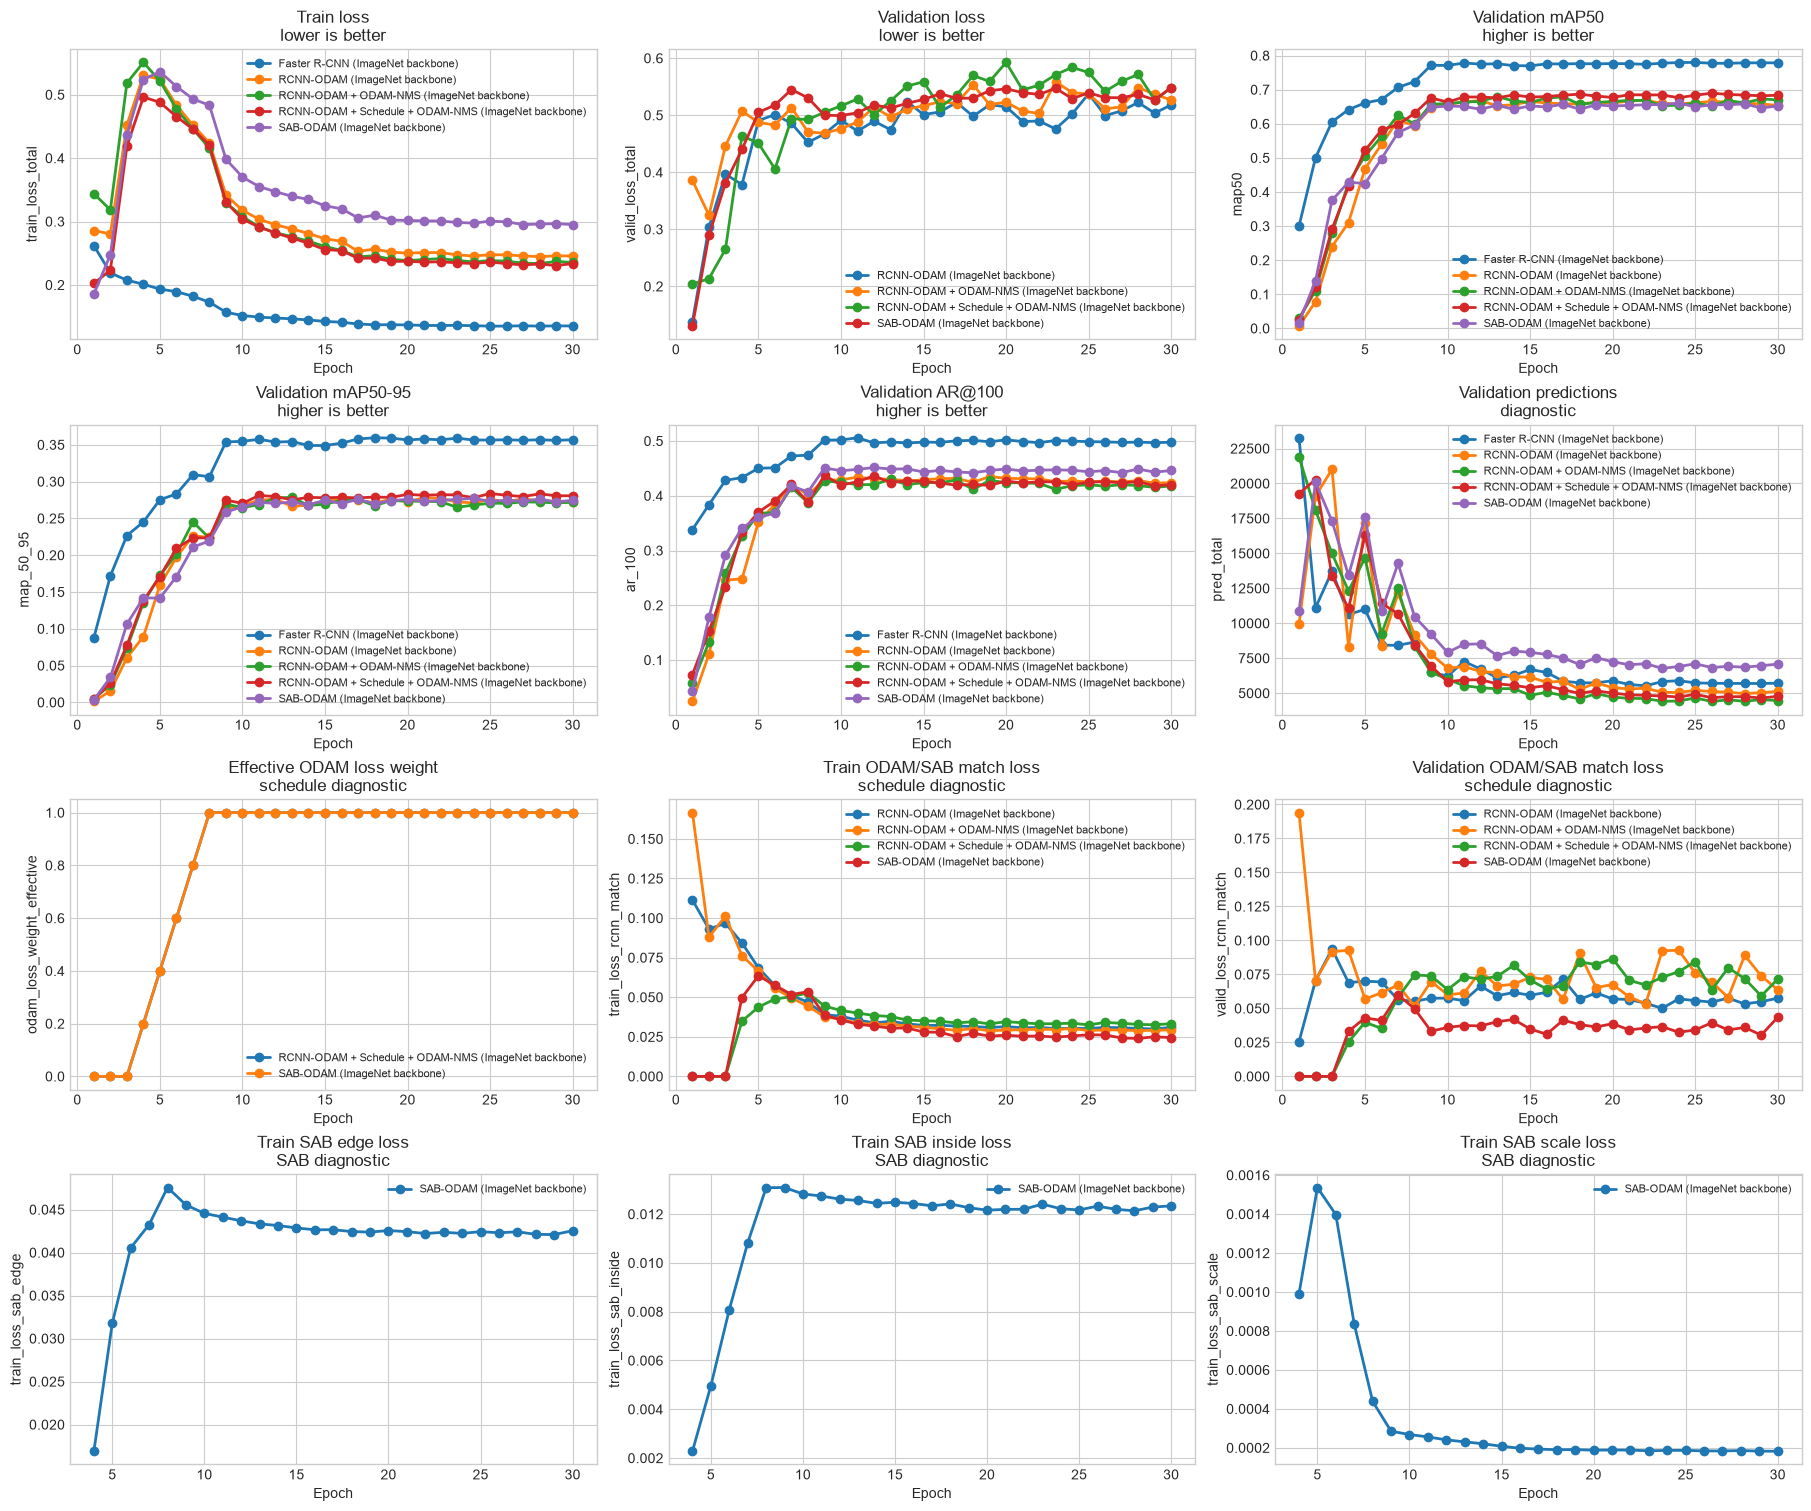

Saved: /home/thanhmay/workspace/xai-object-detection/notebooks/compare_training_results_figures/training_curves.png


In [6]:
def plot_metric_curves(metrics_df: pd.DataFrame) -> Path | None:
    if not HAS_MATPLOTLIB:
        print("matplotlib is unavailable; skipped training curve plots.")
        return None
    if metrics_df.empty:
        print("No metrics to plot.")
        return None

    plots = [
        ("train_loss_total", "Train loss", "lower is better"),
        ("valid_loss_total", "Validation loss", "lower is better"),
        ("map50", "Validation mAP50", "higher is better"),
        ("map_50_95", "Validation mAP50-95", "higher is better"),
        ("ar_100", "Validation AR@100", "higher is better"),
        ("pred_total", "Validation predictions", "diagnostic"),
        ("odam_loss_weight_effective", "Effective ODAM loss weight", "schedule diagnostic"),
        ("train_loss_rcnn_match", "Train ODAM/SAB match loss", "schedule diagnostic"),
        ("valid_loss_rcnn_match", "Validation ODAM/SAB match loss", "schedule diagnostic"),
        ("train_loss_sab_edge", "Train SAB edge loss", "SAB diagnostic"),
        ("train_loss_sab_inside", "Train SAB inside loss", "SAB diagnostic"),
        ("train_loss_sab_scale", "Train SAB scale loss", "SAB diagnostic"),
    ]
    fig, axes = plt.subplots(4, 3, figsize=(18, 15), constrained_layout=True)
    axes = axes.ravel()

    for ax, (column, title, subtitle) in zip(axes, plots):
        drew_line = False
        for run, df in metrics_df.groupby("run", sort=False):
            y = pd.to_numeric(df[column], errors="coerce") if column in df.columns else pd.Series(dtype="float64")
            if y.notna().any():
                ax.plot(df["epoch"], y, marker="o", linewidth=2, label=run)
                drew_line = True
        ax.set_title(f"{title}\n{subtitle}")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(column)
        if drew_line:
            ax.legend(loc="best", fontsize=8)

    path = REPORT_DIR / "training_curves.png"
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    return path


training_curves_path = plot_metric_curves(METRICS_DF)
if training_curves_path:
    print(f"Saved: {training_curves_path}")


## 6. So sánh test metrics

Đây là bảng/biểu đồ quan trọng nhất để báo cáo kết quả sau khi đã train lại các mô hình với điều kiện tương đương. Lưu ý: các run `scratch` và `ImageNet backbone/default` không nên được dùng để kết luận hơn kém trực tiếp; xem bảng fairness ở trên trước khi viết kết luận.


,run,test_map50,test_map_50_95,test_map75,test_ar_100,test_pred_total,test_gt_total,test_loss_total,test_loss_rcnn_match,test_loss_sab_edge,test_loss_sab_inside,test_loss_sab_scale
0,Faster R-CNN (ImageNet backbone),0.787431,0.361373,0.248709,0.503273,4570.0,758.0,NaN,NaN,NaN,NaN,NaN
1,RCNN-ODAM (ImageNet backbone),0.680496,0.277510,0.158642,0.412989,4330.0,758.0,0.165788,0.048990,NaN,NaN,NaN
2,RCNN-ODAM + ODAM-NMS (ImageNet backbone),0.702517,0.294161,0.173484,0.438348,4260.0,758.0,0.163683,0.034166,NaN,NaN,NaN
3,RCNN-ODAM + Schedule + ODAM-NMS (ImageNet back...,0.681066,0.278298,0.159986,0.428741,3715.0,758.0,0.132596,0.026625,NaN,NaN,NaN
4,SAB-ODAM (ImageNet backbone),0.697837,0.288356,0.176840,0.457387,5605.0,758.0,0.203662,0.035165,0.031218,0.007264,0.00011


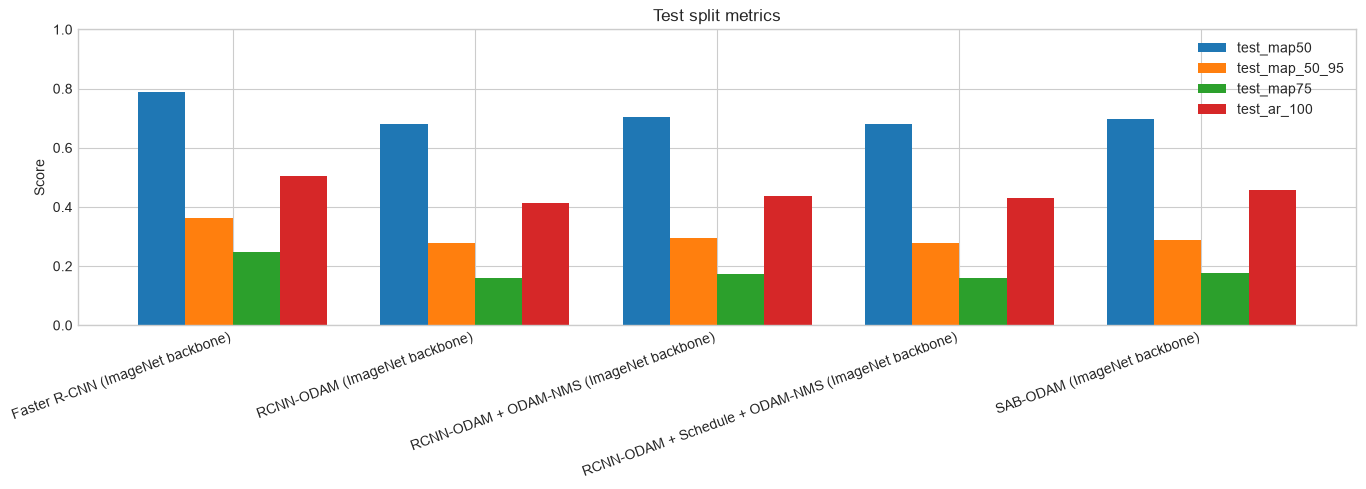

Saved: /home/thanhmay/workspace/xai-object-detection/notebooks/compare_training_results_figures/test_metrics_bar.png


In [7]:
def plot_test_bars(summary_df: pd.DataFrame) -> Path | None:
    if not HAS_MATPLOTLIB:
        print("matplotlib is unavailable; skipped test metric bar plot.")
        return None
    metrics = ["test_map50", "test_map_50_95", "test_map75", "test_ar_100"]
    available = [m for m in metrics if m in summary_df.columns and summary_df[m].notna().any()]
    if summary_df.empty or not available:
        print("No test metrics to plot.")
        return None

    plot_df = summary_df.set_index("run")[available].apply(pd.to_numeric, errors="coerce")
    ax = plot_df.plot(kind="bar", figsize=(14, 5), width=0.78)
    ax.set_title("Test split metrics")
    ax.set_ylabel("Score")
    ax.set_xlabel("")
    ax.set_ylim(0, max(1.0, float(np.nanmax(plot_df.to_numpy())) * 1.15))
    ax.legend(loc="best")
    plt.xticks(rotation=20, ha="right")
    plt.tight_layout()

    path = REPORT_DIR / "test_metrics_bar.png"
    ax.figure.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    return path


if not SUMMARY_DF.empty:
    display_columns = [
        "run",
        "test_map50",
        "test_map_50_95",
        "test_map75",
        "test_ar_100",
        "test_pred_total",
        "test_gt_total",
        "test_loss_total",
        "test_loss_rcnn_match",
        "test_loss_sab_edge",
        "test_loss_sab_inside",
        "test_loss_sab_scale",
    ]
    display(SUMMARY_DF[[c for c in display_columns if c in SUMMARY_DF.columns]])

test_bar_path = plot_test_bars(SUMMARY_DF)
if test_bar_path:
    print(f"Saved: {test_bar_path}")


## 7. AP50 theo từng lớp

Biểu đồ này giúp phát hiện mô hình thắng/thua vì một vài lớp cụ thể hay cải thiện đồng đều. Nếu artifact thiếu AP theo lớp, cell sẽ bỏ qua phần đó.

run,Faster R-CNN (ImageNet backbone),RCNN-ODAM (ImageNet backbone),RCNN-ODAM + ODAM-NMS (ImageNet backbone),RCNN-ODAM + Schedule + ODAM-NMS (ImageNet backbone),SAB-ODAM (ImageNet backbone)
class,,,,,
Broken,0.974038,0.911646,0.940971,0.916659,0.903778
Chipped,0.692255,0.590921,0.585105,0.527272,0.624928
Scratched,0.713137,0.519629,0.592624,0.562791,0.582723
Severe_Rust,0.705422,0.570989,0.553134,0.581468,0.577727
Tip_Wear,0.852303,0.809296,0.840753,0.817139,0.800027
objects,0.000000,0.000000,0.000000,0.000000,0.000000


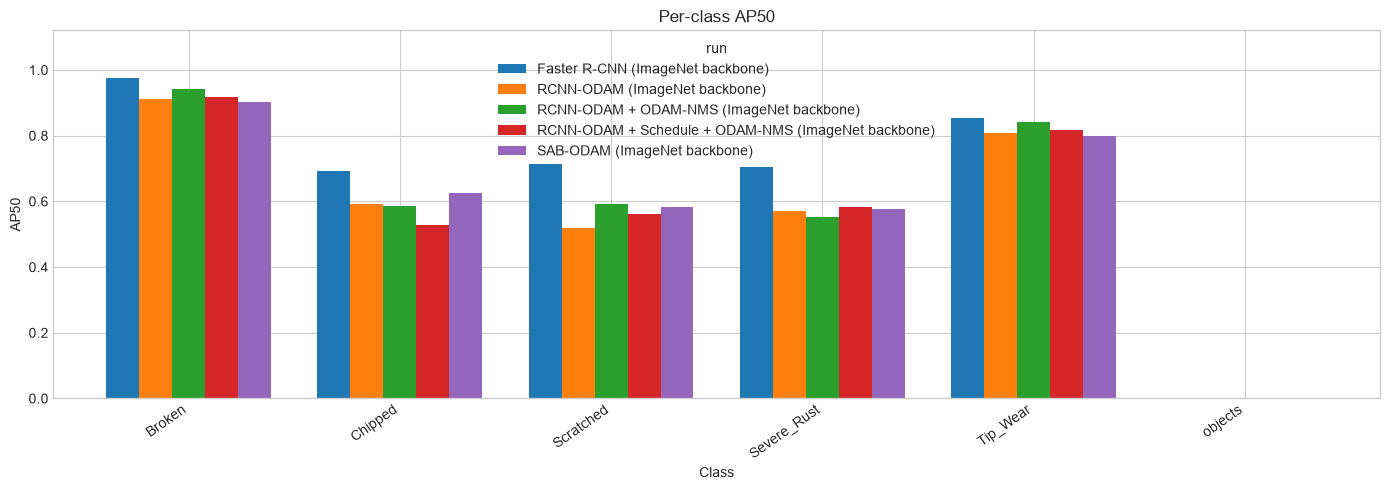

Saved: /home/thanhmay/workspace/xai-object-detection/notebooks/compare_training_results_figures/class_ap50_bar.png


In [8]:
def collect_class_ap50(summary_df: pd.DataFrame, metrics_df: pd.DataFrame) -> pd.DataFrame:
    rows: list[dict[str, Any]] = []

    if not summary_df.empty:
        class_cols = [c for c in summary_df.columns if c.startswith("test_class_") and c.endswith("_ap50")]
        for row in summary_df.itertuples(index=False):
            for column in class_cols:
                value = getattr(row, column)
                if pd.notna(value):
                    class_key = column.removeprefix("test_class_").removesuffix("_ap50")
                    rows.append({"run": row.run, "source": "test", "class": clean_class_label(class_key), "ap50": value})

    if not rows and not metrics_df.empty:
        class_cols = [c for c in metrics_df.columns if c.startswith("class_") and c.endswith("_ap50")]
        best_lookup = BEST_EPOCH_DF.set_index("run")["best_epoch"].to_dict() if not BEST_EPOCH_DF.empty else {}
        for run, df in metrics_df.groupby("run", sort=False):
            best_epoch = best_lookup.get(run, df["epoch"].max())
            best_df = df[df["epoch"] == best_epoch]
            if best_df.empty:
                continue
            row = best_df.iloc[0]
            for column in class_cols:
                value = row[column]
                if pd.notna(value):
                    class_key = column.removeprefix("class_").removesuffix("_ap50")
                    rows.append({"run": run, "source": "validation_best_epoch", "class": clean_class_label(class_key), "ap50": value})

    return pd.DataFrame(rows)


CLASS_AP50_DF = collect_class_ap50(SUMMARY_DF, METRICS_DF)
if CLASS_AP50_DF.empty:
    print("No per-class AP50 metrics available.")
else:
    pivot = CLASS_AP50_DF.pivot_table(index="class", columns="run", values="ap50", aggfunc="first").sort_index()
    display(pivot)
    if HAS_MATPLOTLIB:
        ax = pivot.plot(kind="bar", figsize=(14, 5), width=0.78)
        ax.set_title("Per-class AP50")
        ax.set_ylabel("AP50")
        ax.set_xlabel("Class")
        ax.set_ylim(0, max(1.0, float(np.nanmax(pivot.to_numpy())) * 1.15))
        plt.xticks(rotation=35, ha="right")
        plt.tight_layout()
        class_path = REPORT_DIR / "class_ap50_bar.png"
        ax.figure.savefig(class_path, dpi=160, bbox_inches="tight")
        plt.show()
        print(f"Saved: {class_path}")
    else:
        print("matplotlib is unavailable; skipped per-class AP50 plot.")


## 8. Kết luận nhanh từ artifact hiện tại

Cell cuối tóm tắt chênh lệch số học từ file hiện có. Các cặp delta được khai báo rõ để tránh tự động so `scratch` với `ImageNet backbone/default`. Notebook cũng sinh bảng xếp hạng, delta riêng cho SAB-ODAM, và per-class delta để thấy SAB thắng/thua ở lớp nào.


In [9]:
def metric_delta_table(summary_df: pd.DataFrame) -> pd.DataFrame:
    if summary_df.empty or len(summary_df) < 2:
        return pd.DataFrame()

    metrics = ["test_map50", "test_map_50_95", "test_map75", "test_ar_100", "test_pred_total", "test_map_medium", "test_map_large"]
    rows: list[dict[str, Any]] = []
    planned_comparisons = [
        ("Faster R-CNN (ImageNet backbone)", "SAB-ODAM (ImageNet backbone)", "ImageNet-backbone baseline vs SAB"),
        ("RCNN-ODAM (ImageNet backbone)", "SAB-ODAM (ImageNet backbone)", "plain ODAM vs SAB"),
        ("RCNN-ODAM + ODAM-NMS (ImageNet backbone)", "SAB-ODAM (ImageNet backbone)", "ODAM-NMS vs SAB"),
        ("RCNN-ODAM + Schedule + ODAM-NMS (ImageNet backbone)", "SAB-ODAM (ImageNet backbone)", "schedule plus ODAM-NMS vs SAB"),
        ("RCNN-ODAM (ImageNet backbone)", "RCNN-ODAM + ODAM-NMS (ImageNet backbone)", "ODAM-NMS ablation"),
        ("RCNN-ODAM + ODAM-NMS (ImageNet backbone)", "RCNN-ODAM + Schedule + ODAM-NMS (ImageNet backbone)", "lambda schedule ablation"),
        ("RCNN-ODAM (ImageNet backbone)", "RCNN-ODAM + Schedule + ODAM-NMS (ImageNet backbone)", "schedule plus ODAM-NMS vs plain ODAM"),
        ("Faster R-CNN (scratch)", "SAB-ODAM (scratch)", "scratch baseline vs scratch SAB"),
    ]

    def add_comparison(base_run: str, candidate_run: str, note: str) -> None:
        base_rows = summary_df[summary_df["run"] == base_run]
        candidate_rows = summary_df[summary_df["run"] == candidate_run]
        if base_rows.empty or candidate_rows.empty:
            return
        base = base_rows.iloc[0]
        other = candidate_rows.iloc[0]
        for metric in metrics:
            if metric not in summary_df.columns:
                continue
            base_value = pd.to_numeric(pd.Series([base.get(metric)]), errors="coerce").iloc[0]
            other_value = pd.to_numeric(pd.Series([other.get(metric)]), errors="coerce").iloc[0]
            if pd.isna(base_value) or pd.isna(other_value):
                continue
            rows.append(
                {
                    "comparison": f"{candidate_run} - {base_run}",
                    "comparison_note": note,
                    "metric": metric,
                    "baseline_value": base_value,
                    "candidate_value": other_value,
                    "delta_abs": other_value - base_value,
                    "delta_pct_of_baseline": np.nan if base_value == 0 else (other_value - base_value) / abs(base_value) * 100,
                }
            )

    for base_run, candidate_run, note in planned_comparisons:
        add_comparison(base_run, candidate_run, note)
    return pd.DataFrame(rows)


def rank_test_metrics(summary_df: pd.DataFrame) -> pd.DataFrame:
    metrics = ["test_map50", "test_map_50_95", "test_map75", "test_ar_100", "test_pred_total"]
    rows: list[dict[str, Any]] = []
    for metric in metrics:
        if metric not in summary_df.columns:
            continue
        values = summary_df[["run", metric]].copy()
        values[metric] = pd.to_numeric(values[metric], errors="coerce")
        values = values.dropna().sort_values(metric, ascending=False)
        for rank, row in enumerate(values.itertuples(index=False), start=1):
            rows.append({"metric": metric, "rank": rank, "run": row.run, "value": getattr(row, metric)})
    return pd.DataFrame(rows)


def class_delta_table(class_ap50_df: pd.DataFrame, base_run: str, candidate_run: str) -> pd.DataFrame:
    if class_ap50_df.empty:
        return pd.DataFrame()
    pivot = class_ap50_df.pivot_table(index="class", columns="run", values="ap50", aggfunc="first")
    if base_run not in pivot.columns or candidate_run not in pivot.columns:
        return pd.DataFrame()
    out = pivot[[base_run, candidate_run]].copy()
    out["delta_abs"] = out[candidate_run] - out[base_run]
    out = out.reset_index().rename(columns={base_run: "baseline_ap50", candidate_run: "candidate_ap50"})
    return out.sort_values("delta_abs", ascending=False)


DELTA_DF = metric_delta_table(SUMMARY_DF)
if DELTA_DF.empty:
    print("Need at least two runs with an explicit comparable pair for delta summary.")
else:
    display(DELTA_DF)
    delta_path = REPORT_DIR / "metric_deltas.csv"
    DELTA_DF.to_csv(delta_path, index=False)
    print(f"Saved: {delta_path}")

RANK_DF = rank_test_metrics(SUMMARY_DF)
if RANK_DF.empty:
    print("No test ranking available.")
else:
    display(RANK_DF)
    rank_path = REPORT_DIR / "test_metric_ranks.csv"
    RANK_DF.to_csv(rank_path, index=False)
    print(f"Saved: {rank_path}")

SAB_RUN = "SAB-ODAM (ImageNet backbone)"
BASELINE_RUN = "Faster R-CNN (ImageNet backbone)"
ODAM_NMS_RUN = "RCNN-ODAM + ODAM-NMS (ImageNet backbone)"
SCHEDULE_RUN = "RCNN-ODAM + Schedule + ODAM-NMS (ImageNet backbone)"
PLAIN_ODAM_RUN = "RCNN-ODAM (ImageNet backbone)"

for base_run in [BASELINE_RUN, PLAIN_ODAM_RUN, ODAM_NMS_RUN, SCHEDULE_RUN]:
    class_delta = class_delta_table(CLASS_AP50_DF, base_run, SAB_RUN)
    if not class_delta.empty:
        print(f"Per-class AP50 delta: {SAB_RUN} - {base_run}")
        display(class_delta)

if SAB_RUN in set(SUMMARY_DF.get("run", [])):
    sab_row = SUMMARY_DF[SUMMARY_DF["run"] == SAB_RUN].iloc[0]
    print("SAB-ODAM test summary")
    print(
        "map50={:.4f} map_50_95={:.4f} map75={:.4f} ar_100={:.4f} pred_total={:.0f}".format(
            sab_row.get("test_map50", np.nan),
            sab_row.get("test_map_50_95", np.nan),
            sab_row.get("test_map75", np.nan),
            sab_row.get("test_ar_100", np.nan),
            sab_row.get("test_pred_total", np.nan),
        )
    )

    if BASELINE_RUN in set(SUMMARY_DF["run"]):
        print("Interpretation: SAB-ODAM does not beat the Faster R-CNN ImageNet baseline on the current test metrics.")
    if ODAM_NMS_RUN in set(SUMMARY_DF["run"]):
        print("Interpretation: SAB-ODAM is close to ODAM-NMS on mAP50/mAP50-95, and is better on mAP75/AR@100 in the current artifact.")
    print("Diagnostic: a high pred_total together with stronger AR@100 suggests SAB is recall-oriented but still needs precision/ranking tuning.")

if not CHECKS_DF.empty and (CHECKS_DF["status"] != "MATCH").any():
    print("Fairness warnings exist. Review CHECKS_DF before making a final claim.")
else:
    print("No fairness warning detected by the notebook checks.")


,comparison,comparison_note,metric,baseline_value,candidate_value,delta_abs,delta_pct_of_baseline
0,SAB-ODAM (ImageNet backbone) - Faster R-CNN (I...,ImageNet-backbone baseline vs SAB,test_map50,0.787431,0.697837,-0.089594,-11.378066
1,SAB-ODAM (ImageNet backbone) - Faster R-CNN (I...,ImageNet-backbone baseline vs SAB,test_map_50_95,0.361373,0.288356,-0.073017,-20.205453
2,SAB-ODAM (ImageNet backbone) - Faster R-CNN (I...,ImageNet-backbone baseline vs SAB,test_map75,0.248709,0.176840,-0.071870,-28.897034
3,SAB-ODAM (ImageNet backbone) - Faster R-CNN (I...,ImageNet-backbone baseline vs SAB,test_ar_100,0.503273,0.457387,-0.045886,-9.117566
4,SAB-ODAM (ImageNet backbone) - Faster R-CNN (I...,ImageNet-backbone baseline vs SAB,test_pred_total,4570.000000,5605.000000,1035.000000,22.647702
5,SAB-ODAM (ImageNet backbone) - Faster R-CNN (I...,ImageNet-backbone baseline vs SAB,test_map_medium,0.293861,0.218292,-0.075570,-25.716099
6,SAB-ODAM (ImageNet backbone) - Faster R-CNN (I...,ImageNet-backbone baseline vs SAB,test_map_large,0.404386,0.341950,-0.062435,-15.439545
7,SAB-ODAM (ImageNet backbone) - RCNN-ODAM (Imag...,plain ODAM vs SAB,test_map50,0.680496,0.697837,0.017340,2.548206
8,SAB-ODAM (ImageNet backbone) - RCNN-ODAM (Imag...,plain ODAM vs SAB,test_map_50_95,0.277510,0.288356,0.010846,3.908461
9,SAB-ODAM (ImageNet backbone) - RCNN-ODAM (Imag...,plain ODAM vs SAB,test_map75,0.158642,0.176840,0.018198,11.471151


Saved: /home/thanhmay/workspace/xai-object-detection/notebooks/compare_training_results_figures/metric_deltas.csv


,metric,rank,run,value
0,test_map50,1,Faster R-CNN (ImageNet backbone),0.787431
1,test_map50,2,RCNN-ODAM + ODAM-NMS (ImageNet backbone),0.702517
2,test_map50,3,SAB-ODAM (ImageNet backbone),0.697837
3,test_map50,4,RCNN-ODAM + Schedule + ODAM-NMS (ImageNet back...,0.681066
4,test_map50,5,RCNN-ODAM (ImageNet backbone),0.680496
5,test_map_50_95,1,Faster R-CNN (ImageNet backbone),0.361373
6,test_map_50_95,2,RCNN-ODAM + ODAM-NMS (ImageNet backbone),0.294161
7,test_map_50_95,3,SAB-ODAM (ImageNet backbone),0.288356
8,test_map_50_95,4,RCNN-ODAM + Schedule + ODAM-NMS (ImageNet back...,0.278298
9,test_map_50_95,5,RCNN-ODAM (ImageNet backbone),0.277510


Saved: /home/thanhmay/workspace/xai-object-detection/notebooks/compare_training_results_figures/test_metric_ranks.csv
Per-class AP50 delta: SAB-ODAM (ImageNet backbone) - Faster R-CNN (ImageNet backbone)


run,class,baseline_ap50,candidate_ap50,delta_abs
5,objects,0.000000,0.000000,0.000000
4,Tip_Wear,0.852303,0.800027,-0.052275
1,Chipped,0.692255,0.624928,-0.067327
0,Broken,0.974038,0.903778,-0.070260
3,Severe_Rust,0.705422,0.577727,-0.127695
2,Scratched,0.713137,0.582723,-0.130414


...

Per-class AP50 delta: SAB-ODAM (ImageNet backbone) - RCNN-ODAM + ODAM-NMS (ImageNet backbone)


run,class,baseline_ap50,candidate_ap50,delta_abs
1,Chipped,0.585105,0.624928,0.039823
3,Severe_Rust,0.553134,0.577727,0.024593
5,objects,0.000000,0.000000,0.000000
2,Scratched,0.592624,0.582723,-0.009901
0,Broken,0.940971,0.903778,-0.037193
4,Tip_Wear,0.840753,0.800027,-0.040726


Per-class AP50 delta: SAB-ODAM (ImageNet backbone) - RCNN-ODAM + Schedule + ODAM-NMS (ImageNet backbone)


run,class,baseline_ap50,candidate_ap50,delta_abs
1,Chipped,0.527272,0.624928,0.097656
2,Scratched,0.562791,0.582723,0.019932
5,objects,0.000000,0.000000,0.000000
3,Severe_Rust,0.581468,0.577727,-0.003741
0,Broken,0.916659,0.903778,-0.012881
4,Tip_Wear,0.817139,0.800027,-0.017112


SAB-ODAM test summary
map50=0.6978 map_50_95=0.2884 map75=0.1768 ar_100=0.4574 pred_total=5605
Interpretation: SAB-ODAM does not beat the Faster R-CNN ImageNet baseline on the current test metrics.
Interpretation: SAB-ODAM is close to ODAM-NMS on mAP50/mAP50-95, and is better on mAP75/AR@100 in the current artifact.
Diagnostic: a high pred_total together with stronger AR@100 suggests SAB is recall-oriented but still needs precision/ranking tuning.
Fairness warnings exist. Review CHECKS_DF before making a final claim.
